In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

%matplotlib inline

In [2]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

category = pd.read_csv(
    "../data/raw/05_category_inflows.csv"
)

folio = pd.read_csv(
    "../data/raw/06_industry_folio_count.csv"
)

transactions = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

In [3]:
datasets = {
    "fund_master": fund_master,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "transactions": transactions,
    "performance": performance
}

for name, df in datasets.items():

    print("\n" + "="*60)

    print(name)

    print("Shape:", df.shape)


fund_master
Shape: (40, 15)

aum
Shape: (90, 5)

sip
Shape: (48, 6)

category
Shape: (144, 3)

folio
Shape: (21, 6)

transactions
Shape: (32778, 13)

performance
Shape: (40, 19)


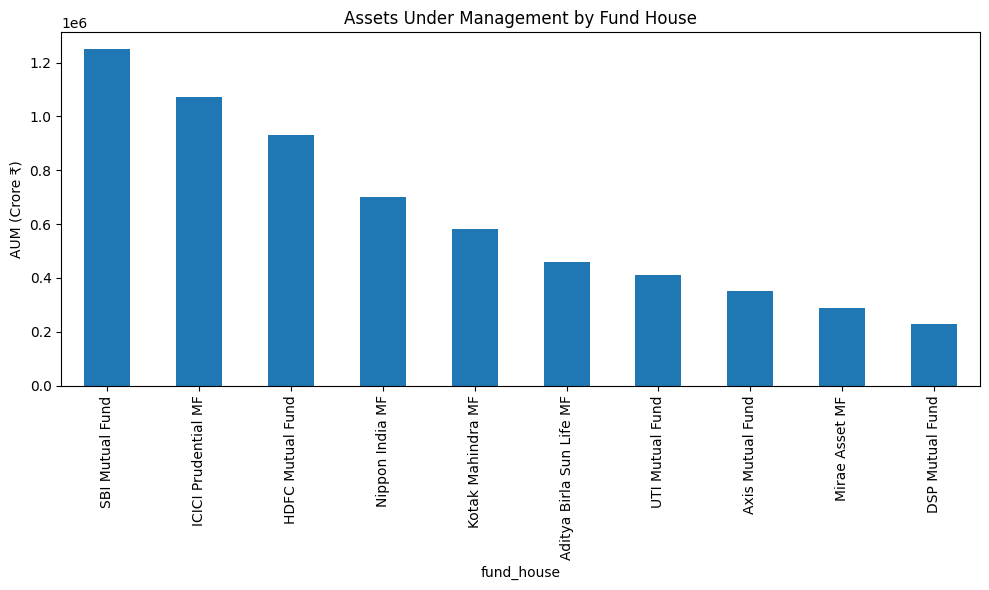

In [4]:
aum_latest = (
    aum
    .groupby("fund_house")["aum_crore"]
    .max()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

aum_latest.plot(kind="bar")

plt.title(
    "Assets Under Management by Fund House"
)

plt.ylabel("AUM (Crore ₹)")

plt.tight_layout()

plt.show()

In [5]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

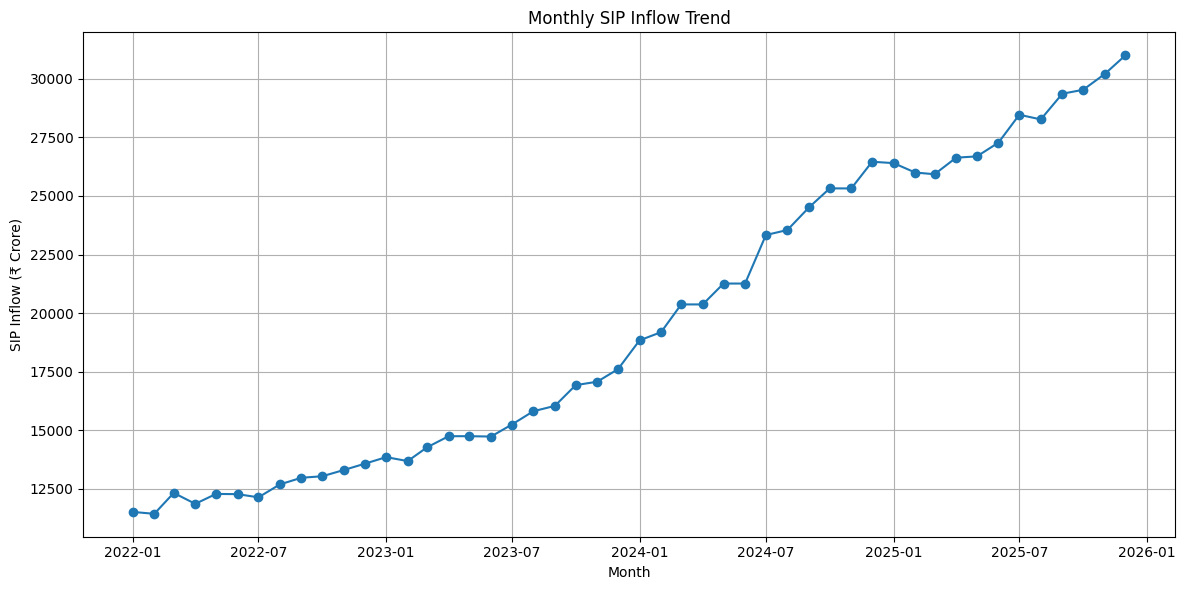

In [8]:
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    marker='o'
)

plt.title("Monthly SIP Inflow Trend")

plt.xlabel("Month")

plt.ylabel("SIP Inflow (₹ Crore)")

plt.grid(True)

plt.tight_layout()

plt.show()

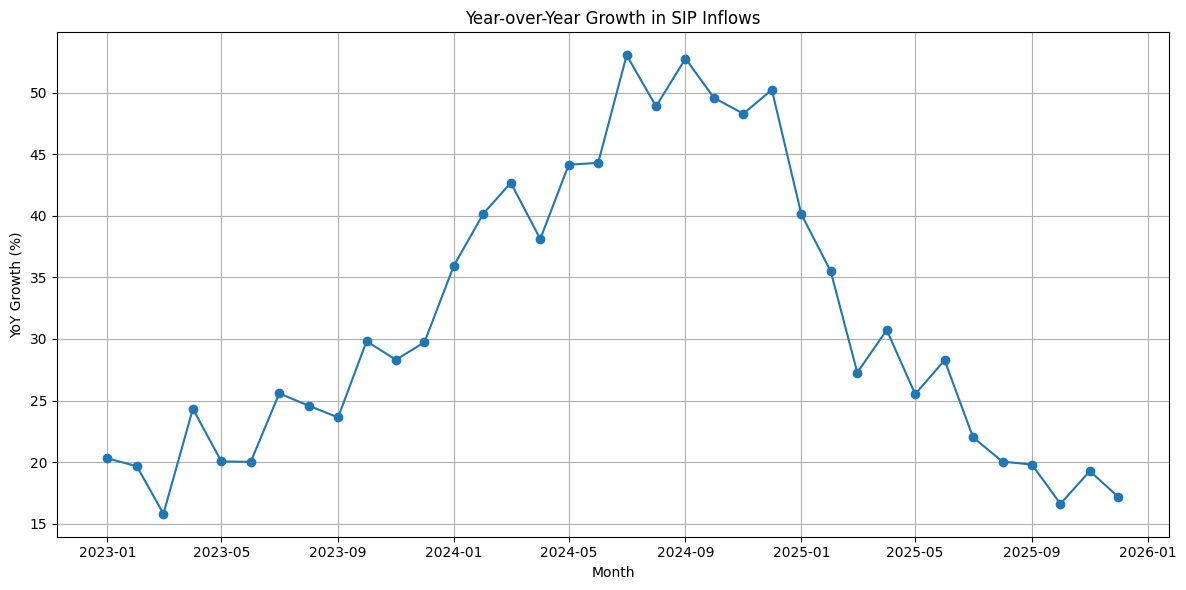

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['yoy_growth_pct'],
    marker='o'
)

plt.title("Year-over-Year Growth in SIP Inflows")

plt.xlabel("Month")

plt.ylabel("YoY Growth (%)")

plt.grid(True)

plt.tight_layout()

plt.show()

In [10]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [11]:
category.columns.tolist()

['month', 'category', 'net_inflow_crore']

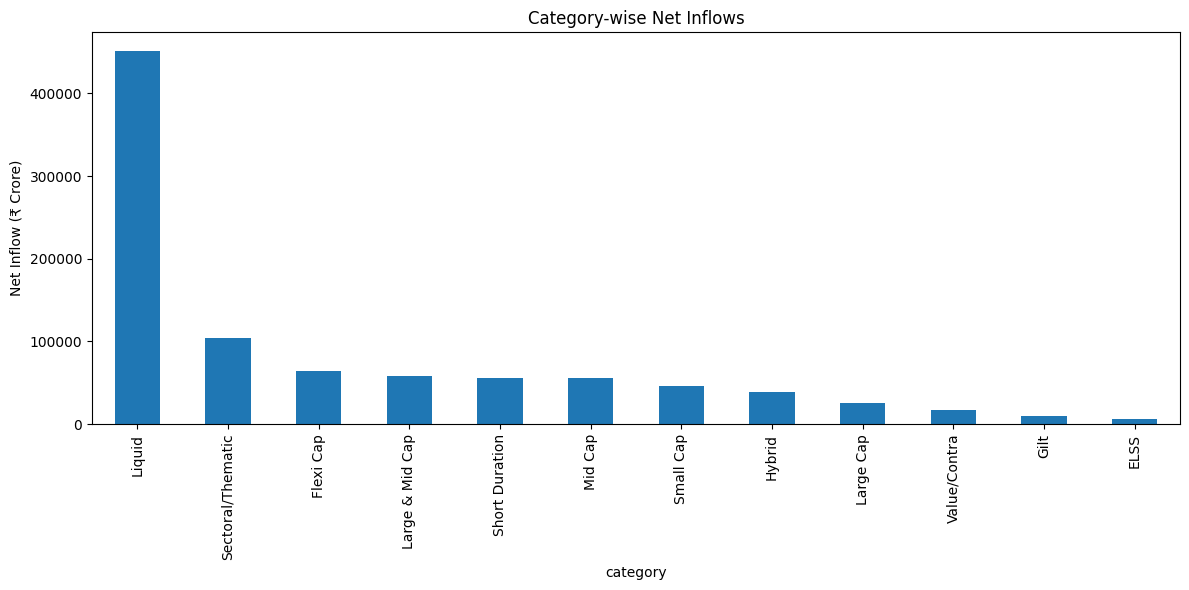

In [12]:
category_totals = (
    category
    .groupby('category')['net_inflow_crore']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

category_totals.plot(kind='bar')

plt.title("Category-wise Net Inflows")

plt.ylabel("Net Inflow (₹ Crore)")

plt.tight_layout()

plt.show()

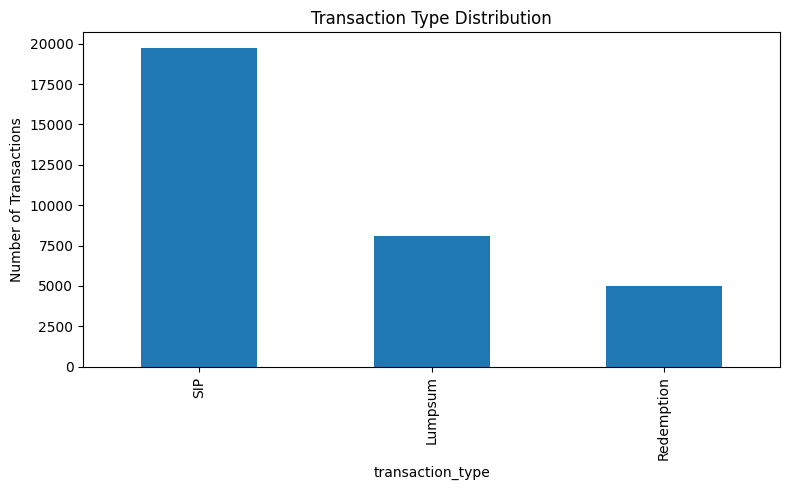

In [13]:
transactions['transaction_type'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Transaction Type Distribution")

plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.show()

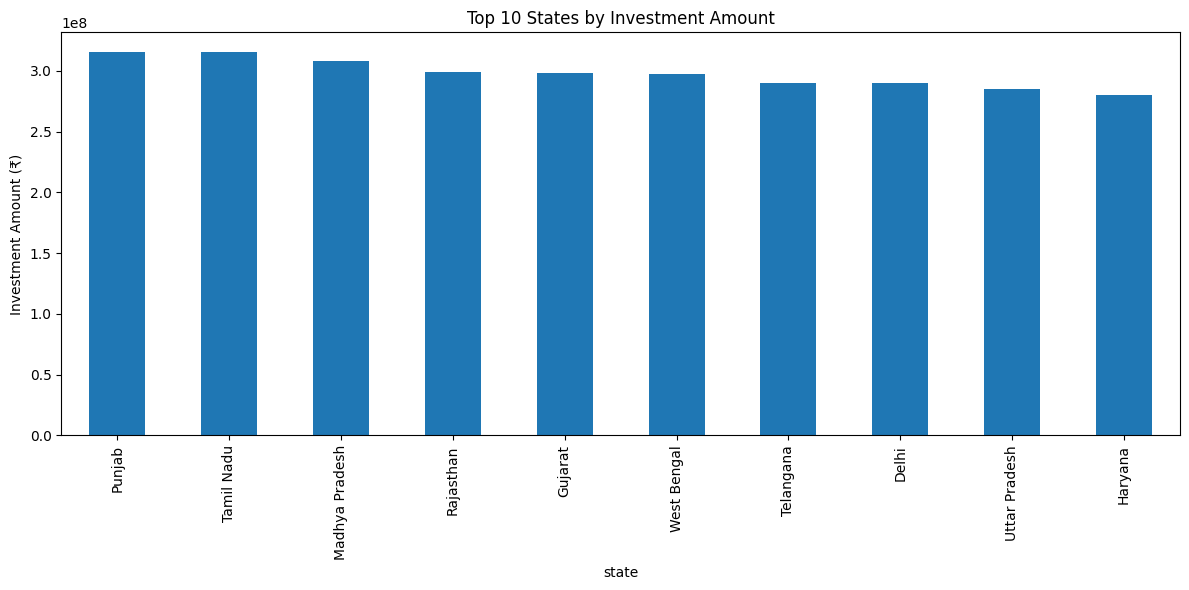

In [14]:
state_investment = (
    transactions
    .groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

state_investment.plot(kind='bar')

plt.title("Top 10 States by Investment Amount")

plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.show()

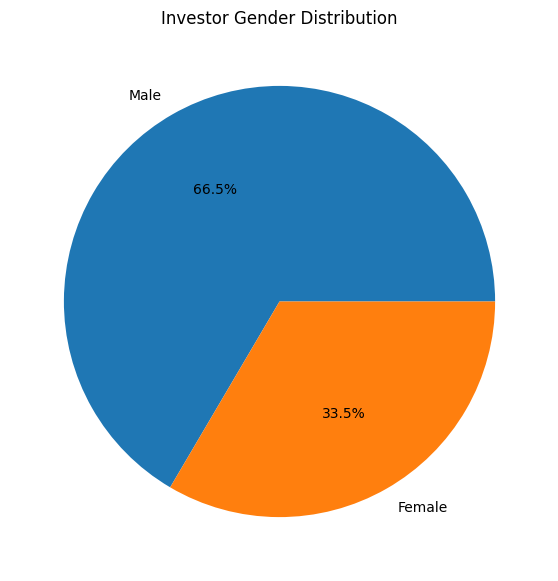

In [15]:
transactions['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Investor Gender Distribution")

plt.ylabel("")

plt.show()

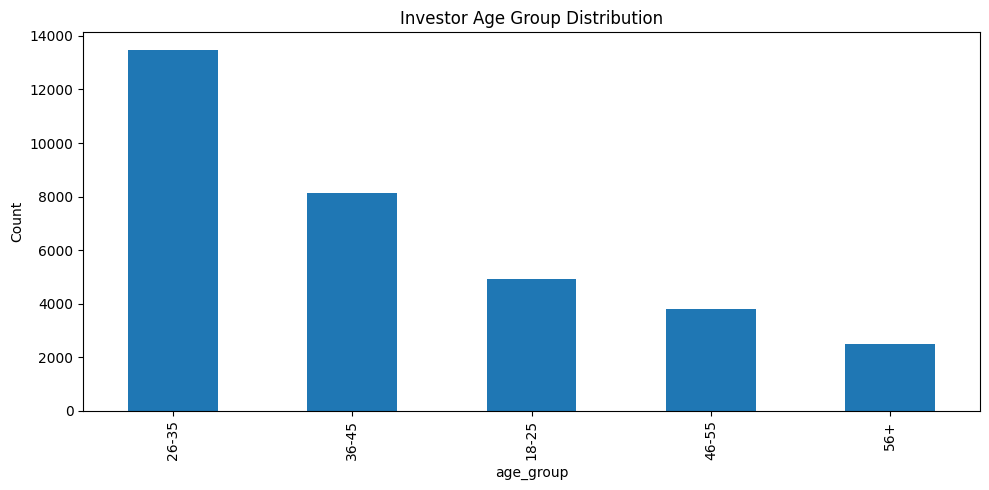

In [16]:
transactions['age_group'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Investor Age Group Distribution")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

In [17]:
transactions['city_tier'].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

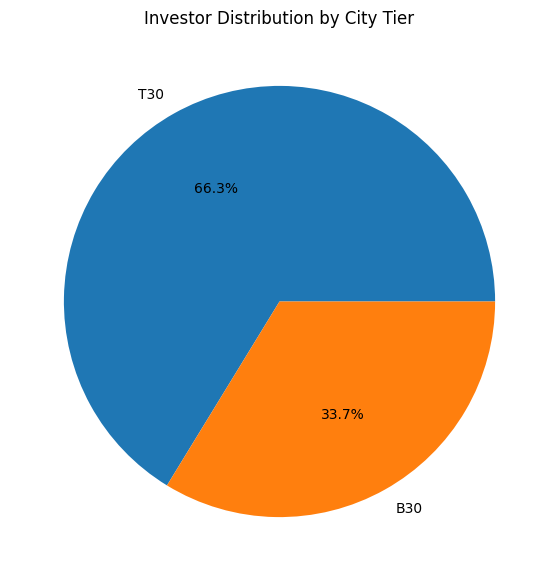

In [18]:
transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Investor Distribution by City Tier")

plt.ylabel("")

plt.show()

In [21]:
transactions['annual_income_lakh'].describe()

count    32778.000000
mean        26.181219
std         20.805425
min          3.000000
25%         10.600000
50%         19.700000
75%         37.400000
max         99.700000
Name: annual_income_lakh, dtype: float64

In [22]:
performance['risk_grade'].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

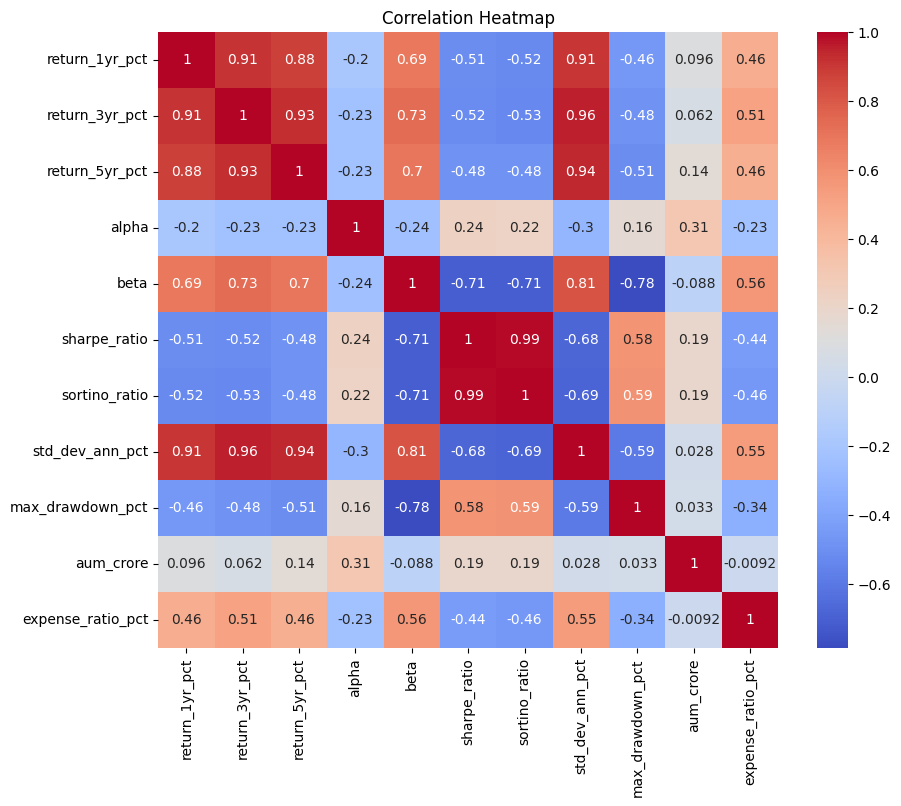

In [23]:
numeric_cols = [
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct',
    'alpha',
    'beta',
    'sharpe_ratio',
    'sortino_ratio',
    'std_dev_ann_pct',
    'max_drawdown_pct',
    'aum_crore',
    'expense_ratio_pct'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    performance[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

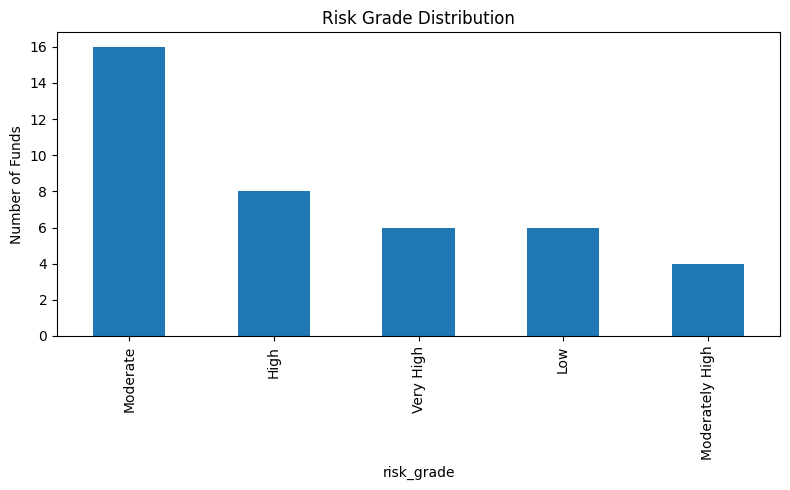

In [24]:
performance['risk_grade'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Risk Grade Distribution")

plt.ylabel("Number of Funds")

plt.tight_layout()

plt.show()

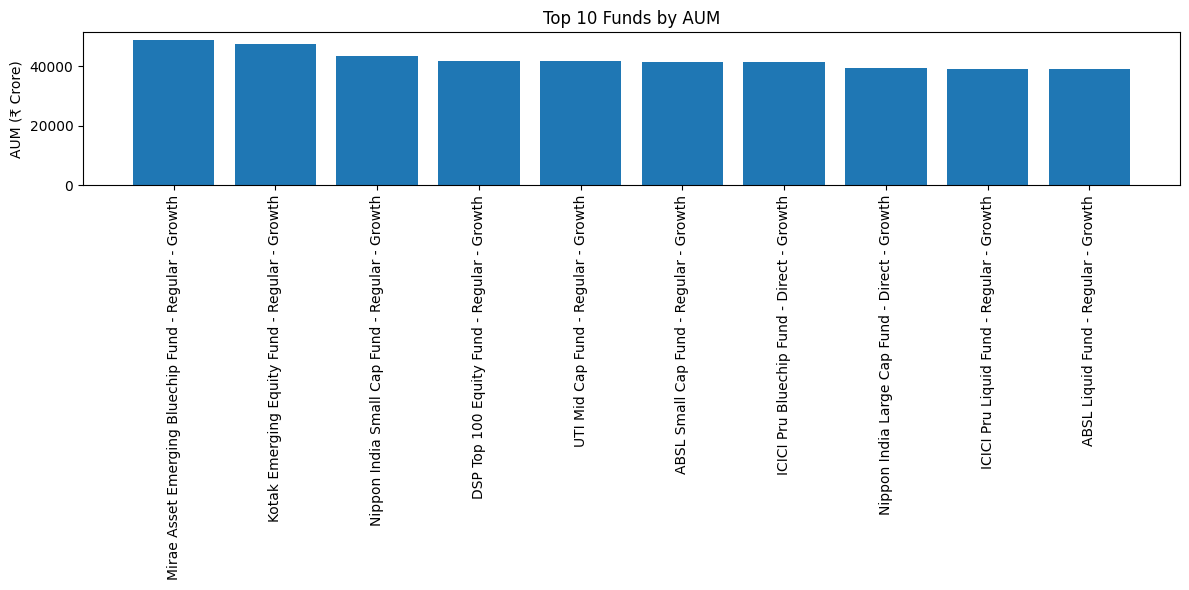

In [25]:
top_funds = (
    performance
    .sort_values(
        by='aum_crore',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    top_funds['scheme_name'],
    top_funds['aum_crore']
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by AUM")

plt.ylabel("AUM (₹ Crore)")

plt.tight_layout()

plt.show()

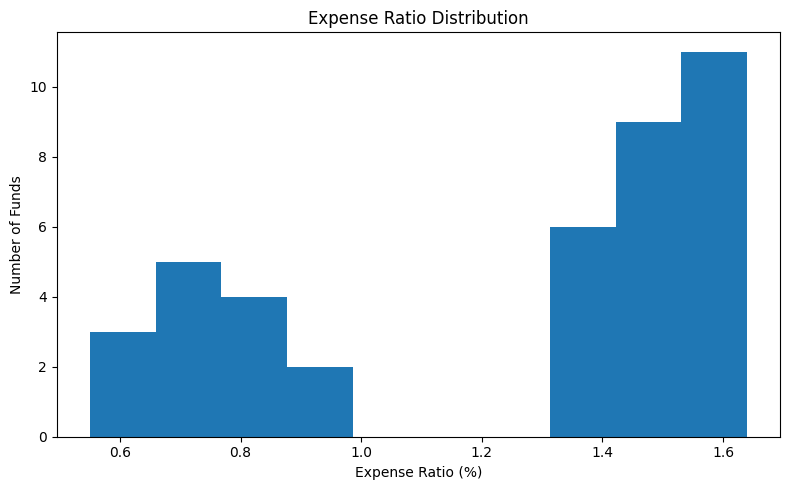

In [26]:
plt.figure(figsize=(8,5))

plt.hist(
    performance['expense_ratio_pct'],
    bins=10
)

plt.title("Expense Ratio Distribution")

plt.xlabel("Expense Ratio (%)")

plt.ylabel("Number of Funds")

plt.tight_layout()

plt.show()

In [1]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

print(nav.columns.tolist())

print(nav.head())

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

print(nav.columns.tolist())

print(nav.head())

['amfi_code', 'date', 'nav']
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [5]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.columns.tolist())

print(aum.head())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


In [6]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.columns.tolist())

print(folio.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


In [7]:
portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(portfolio.columns.tolist())

print(portfolio.head())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


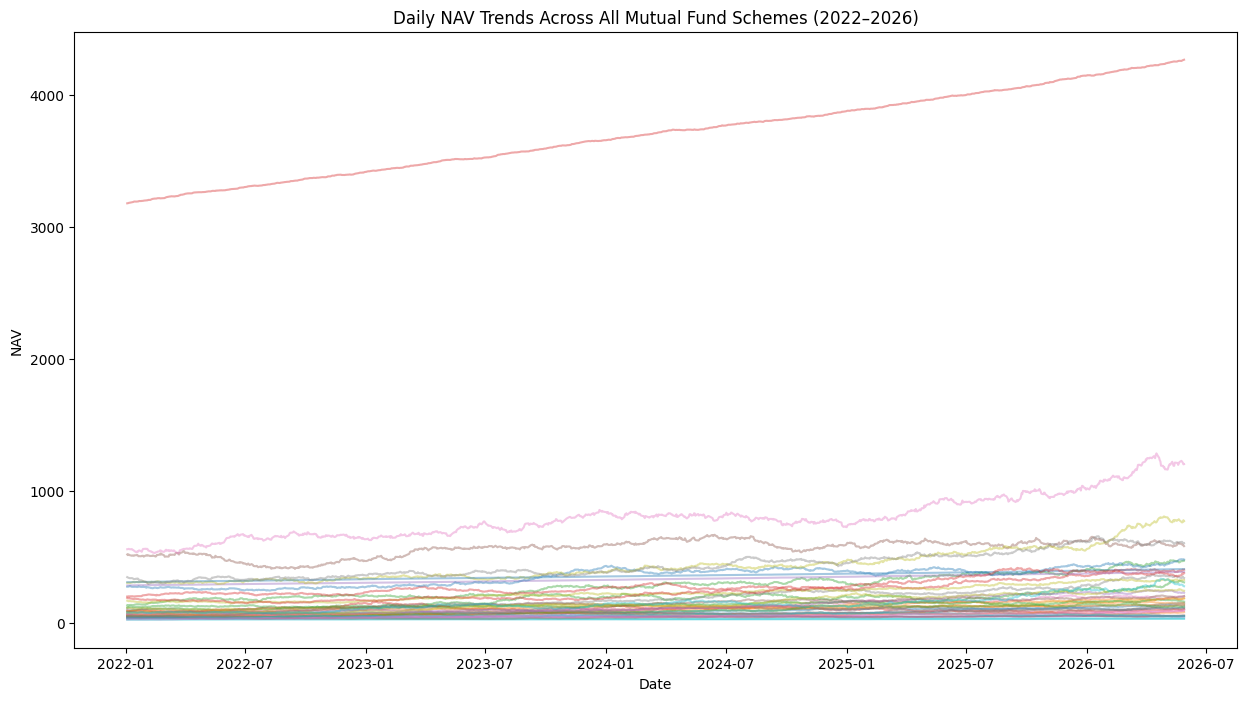

In [7]:
nav['date'] = pd.to_datetime(nav['date'])

plt.figure(figsize=(15,8))

for scheme in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == scheme
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        alpha=0.4
    )

plt.title(
    "Daily NAV Trends Across All Mutual Fund Schemes (2022–2026)"
)
plt.savefig(
    "../reports/charts/nav_trends.png",
    bbox_inches='tight'
)
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

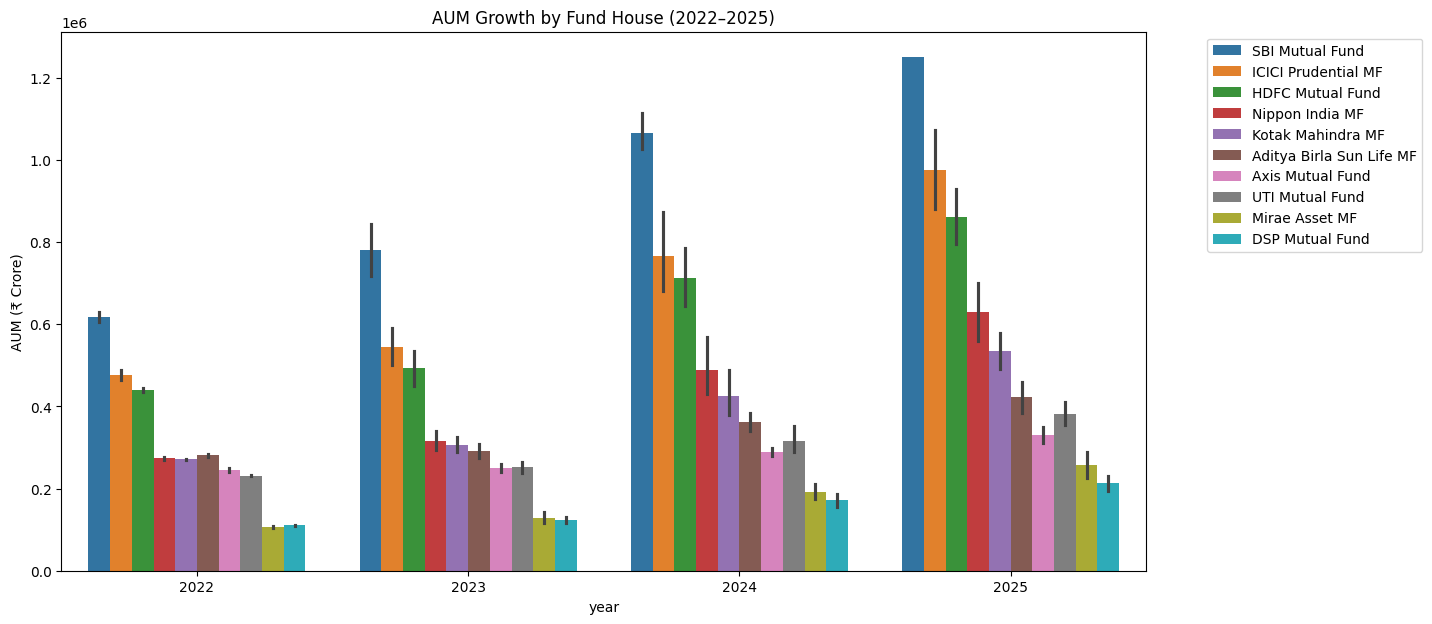

In [8]:
aum['date'] = pd.to_datetime(aum['date'])

aum['year'] = aum['date'].dt.year

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x='year',
    y='aum_crore',
    hue='fund_house'
)

plt.title(
    "AUM Growth by Fund House (2022–2025)"
)

plt.ylabel("AUM (₹ Crore)")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)
plt.savefig(
    "../reports/charts/aum_growth.png",
    bbox_inches='tight'
)

plt.show()

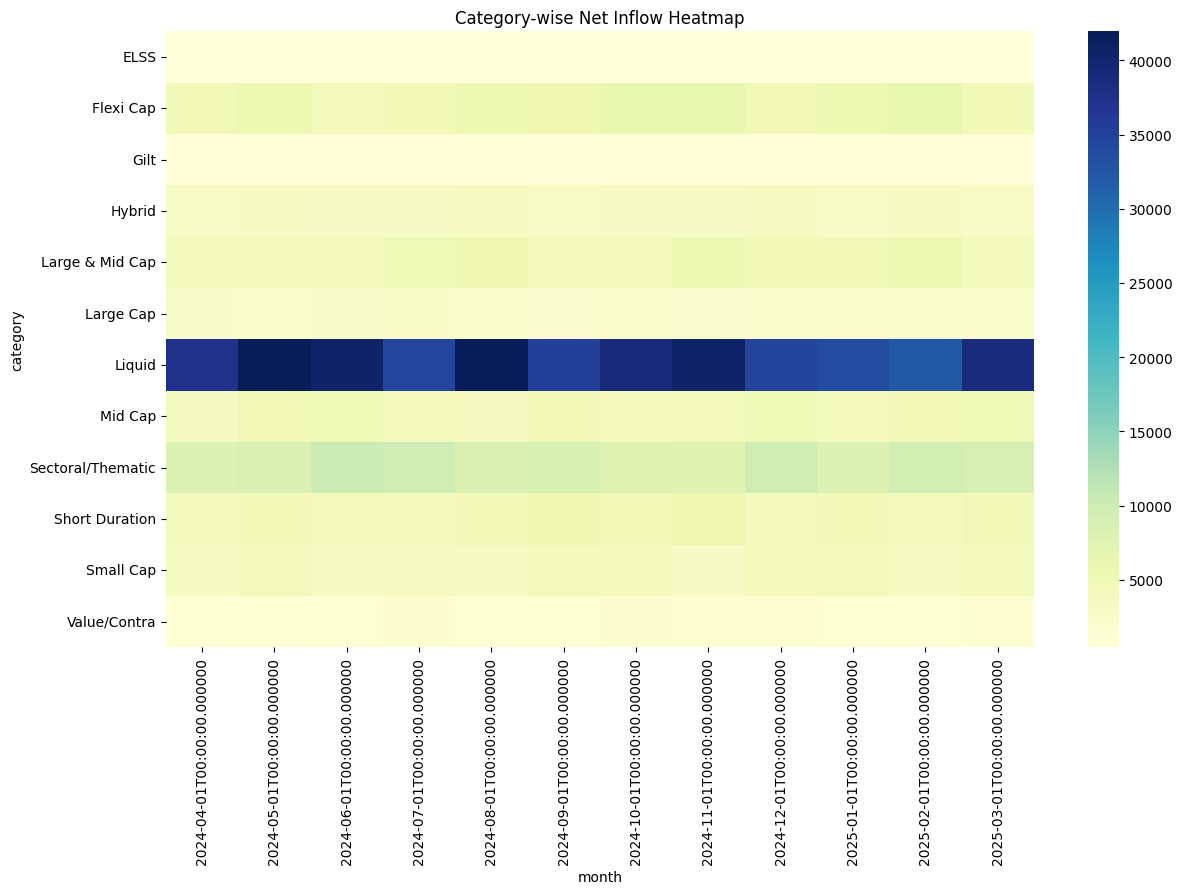

In [9]:
category['month'] = pd.to_datetime(category['month'])

heatmap_data = category.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore',
    aggfunc='sum'
)

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title(
    "Category-wise Net Inflow Heatmap"
)
plt.savefig(
    "../reports/charts/inflow_heatmap.png",
    bbox_inches='tight'
)

plt.show()

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

category = pd.read_csv(
    "../data/raw/05_category_inflows.csv"
)

print(category.head())

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x='age_group',
    y='amount_inr'
)

plt.title(
    "Investment Amount Distribution by Age Group"
)

plt.show()

NameError: name 'transactions' is not defined

<Figure size 1000x600 with 0 Axes>

In [14]:
transactions = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

print(transactions.shape)

(32778, 13)


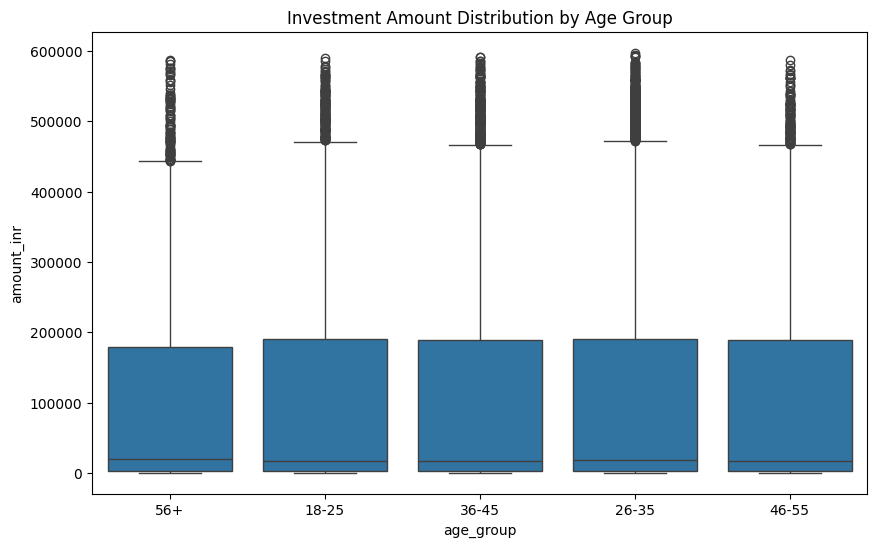

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x='age_group',
    y='amount_inr'
)

plt.title(
    "Investment Amount Distribution by Age Group"
)
plt.savefig(
    "../reports/charts/age_group.png",
    bbox_inches='tight'
)
plt.show()

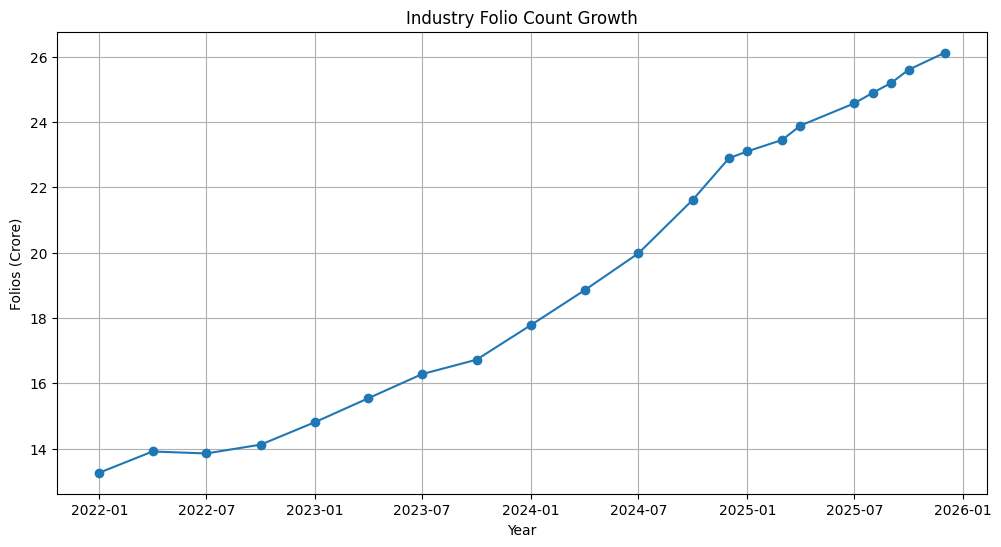

In [11]:
folio['month'] = pd.to_datetime(
    folio['month']
)

plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.title(
    "Industry Folio Count Growth"
)
plt.savefig(
    "../reports/charts/folio_count.png",
    bbox_inches='tight'
)

plt.ylabel(
    "Folios (Crore)"
)

plt.xlabel("Year")

plt.grid(True)

plt.show()

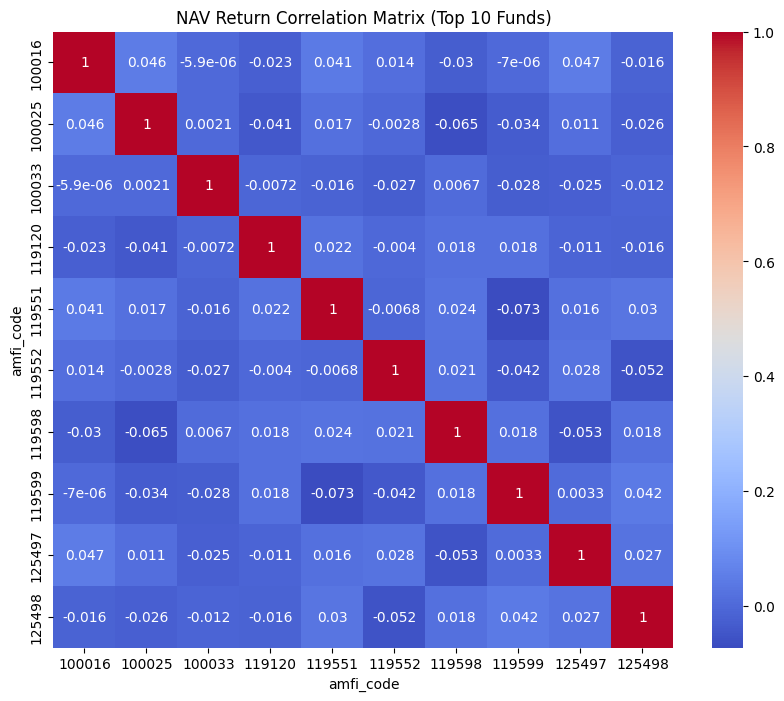

In [12]:
nav['date'] = pd.to_datetime(nav['date'])

top_10_funds = (
    nav['amfi_code']
    .unique()[:10]
)

nav_subset = nav[
    nav['amfi_code']
    .isin(top_10_funds)
]

pivot_nav = nav_subset.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

returns = pivot_nav.pct_change()

plt.figure(figsize=(10,8))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "NAV Return Correlation Matrix (Top 10 Funds)"
)
plt.savefig(
    "../reports/charts/correlation_matrix.png",
    bbox_inches='tight'
)

plt.show()

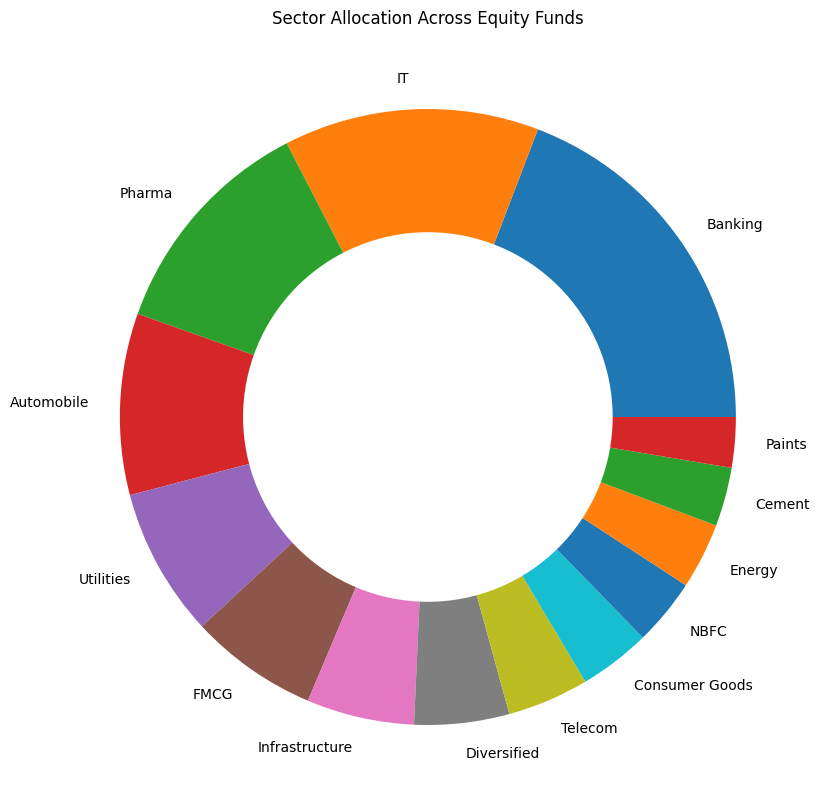

In [13]:
sector_data = (
    portfolio
    .groupby('sector')['weight_pct']
    .sum()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(10,10))

wedges, texts = plt.pie(
    sector_data,
    labels=sector_data.index
)

centre_circle = plt.Circle(
    (0,0),
    0.60,
    fc='white'
)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title(
    "Sector Allocation Across Equity Funds"
)
plt.savefig(
    "../reports/charts/equity_funds.png",
    bbox_inches='tight'
)
plt.show()

In [6]:
portfolio.columns.tolist()

NameError: name 'portfolio' is not defined

In [7]:
portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(portfolio.shape)

print(portfolio.columns.tolist())

NameError: name 'pd' is not defined

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(portfolio.shape)

print(portfolio.columns.tolist())

portfolio.head()

(322, 8)
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [10]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [2]:
import os

os.makedirs(
    "../reports/charts",
    exist_ok=True
)

print("Charts folder created successfully!")

Charts folder created successfully!


In [3]:
import os

print(os.path.exists("../reports/charts"))

True


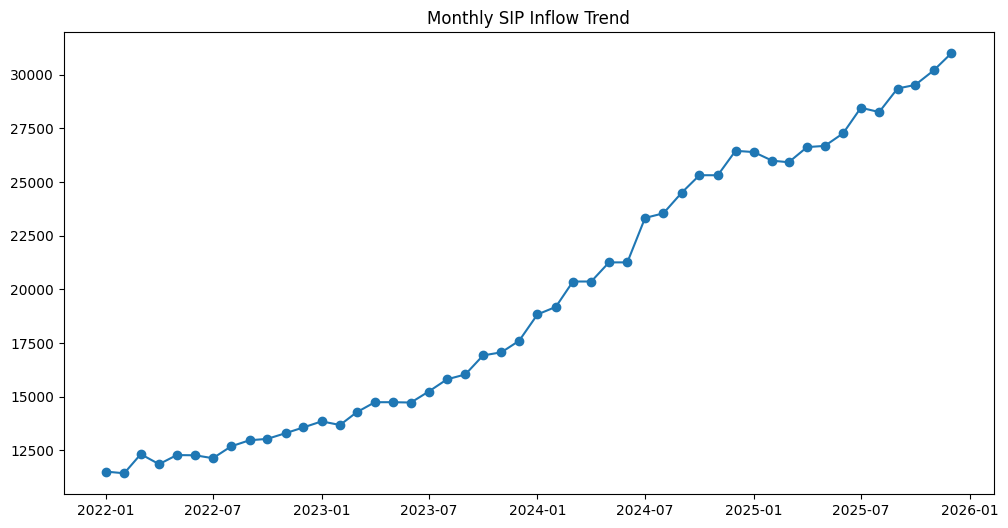

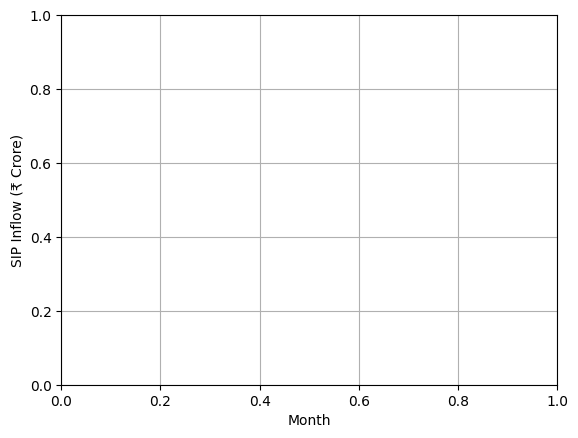

In [14]:
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    marker='o'
)

plt.title("Monthly SIP Inflow Trend")
plt.savefig(
    "../reports/charts/sip_trend.png",
    bbox_inches='tight'
)

plt.show()

plt.xlabel("Month")

plt.ylabel("SIP Inflow (₹ Crore)")

plt.grid(True)

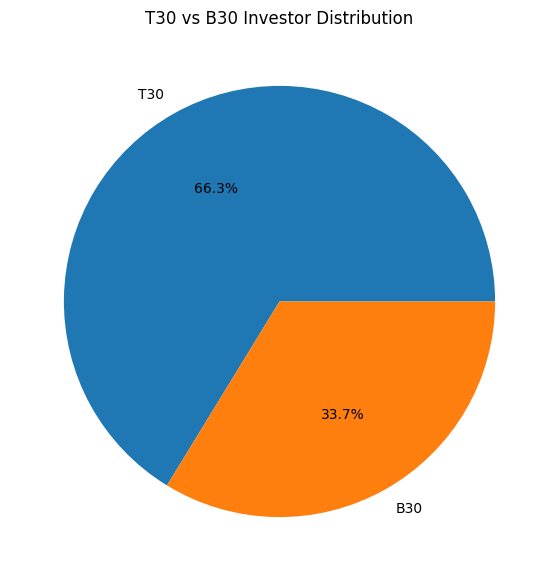

Text(0, 0.5, '')

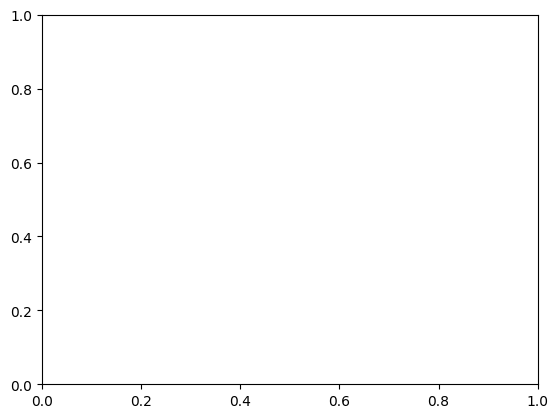

In [15]:
transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title(
    "T30 vs B30 Investor Distribution"
)
plt.savefig(
    "../reports/charts/t30_b30_distribution.png",
    bbox_inches='tight'
)

plt.show()

plt.ylabel("")